<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets --upgrade --quiet

In [20]:
import opendatasets as od
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet


В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [4]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data?select=train.csv'

In [5]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: veronikapasichnyk
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 464MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-3/bank-customer-churn-prediction-dlu-course-c-3.zip to ./bank-customer-churn-prediction-dlu-course-c-3


In [6]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'

In [7]:
os.listdir(data_dir)

['train.csv', 'test.csv', 'sample_submission.csv']

In [8]:
train_csv = data_dir + '/train.csv'

Area under ROC score on Train dataset: 0.77%


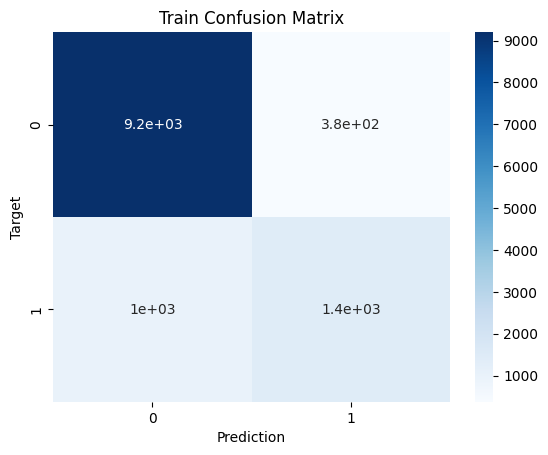

Area under ROC score on Validation dataset: 0.76%


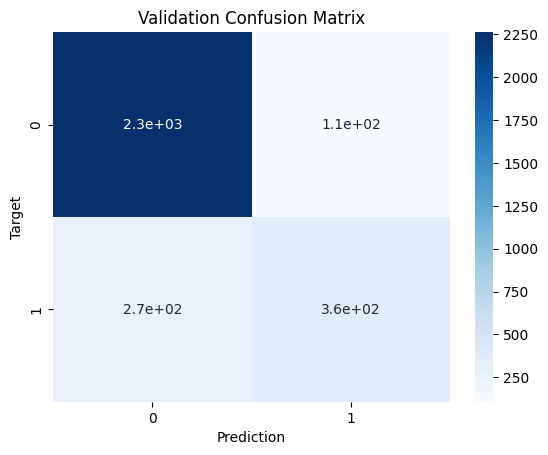

['model_pipeline.pkl']

In [9]:
raw_df = pd.read_csv(train_csv, index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
input_cols = [col for col in raw_df.columns if col != 'Exited']
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(targets, preds)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'model_pipeline.pkl')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train (Poly) dataset: 0.84%


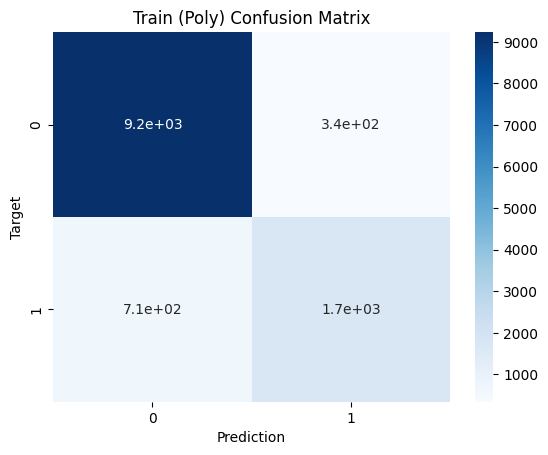

Area under ROC score on Validation (Poly) dataset: 0.80%


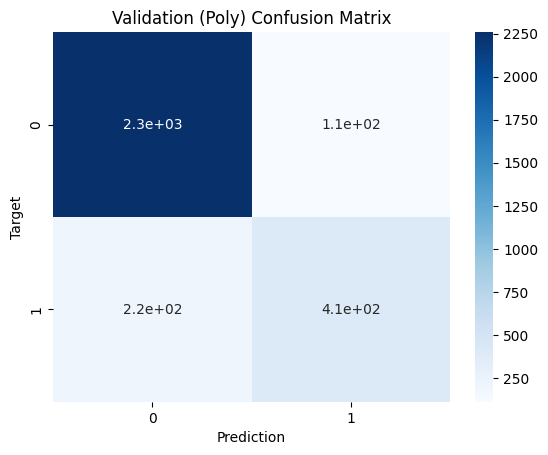

In [10]:
# Новий трансформер для числових колонок з PolynomialFeatures
numeric_poly_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Новий комбінований препроцесор
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_poly_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Новий пайплайн з поліноміальними ознаками
poly_model_pipeline = Pipeline(steps=[
    ('preprocessor', poly_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#Навчання моделі
poly_model_pipeline.fit(train_inputs, train_targets)

# Оцінка моделі (функція вже створена раніше, можемо повторно використати її)
train_preds_poly = predict_and_plot(poly_model_pipeline, train_inputs, train_targets, name='Train (Poly)')
val_preds_poly = predict_and_plot(poly_model_pipeline, val_inputs, val_targets, name='Validation (Poly)')

**Спостереження**

Train AUC: 0.84%

Validation AUC: 0.80%

Такі значення свідчать про хорошу генералізацію моделі:

- Різниця між Train і Validation — лише 0.04 (4%), тобто модель, не перенавчилась (немає overfit), не занадто проста (немає underfit), добре адаптується до нових, ще не бачених даних.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train (Poly) dataset: 0.84%


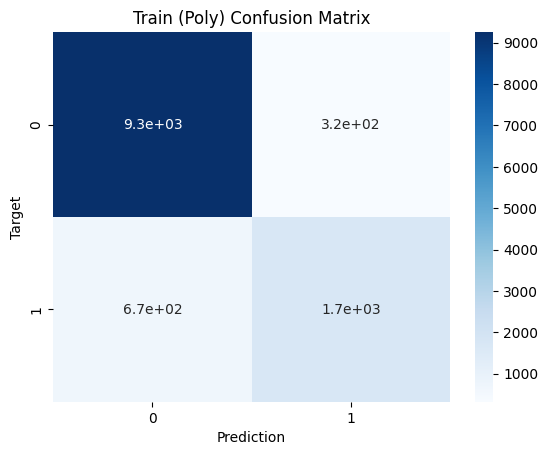

Area under ROC score on Validation (Poly) dataset: 0.79%


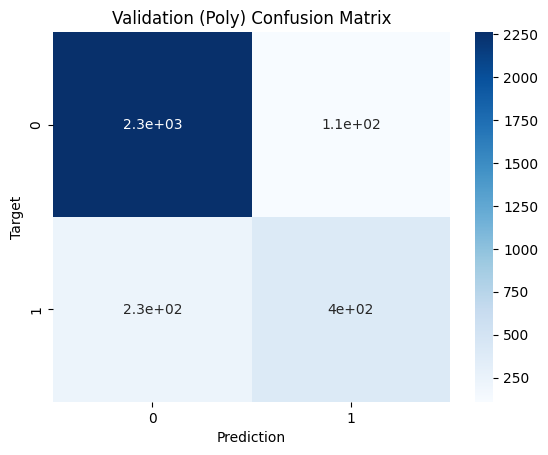

In [11]:
# Новий трансформер для числових колонок з PolynomialFeatures
numeric_poly_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

# Новий комбінований препроцесор
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_poly_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Новий пайплайн з поліноміальними ознаками
poly_model_pipeline = Pipeline(steps=[
    ('preprocessor', poly_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#Навчання моделі
poly_model_pipeline.fit(train_inputs, train_targets)

# Оцінка моделі (функція вже створена раніше, можемо повторно використати її)
train_preds_poly = predict_and_plot(poly_model_pipeline, train_inputs, train_targets, name='Train (Poly)')
val_preds_poly = predict_and_plot(poly_model_pipeline, val_inputs, val_targets, name='Validation (Poly)')

Train AUC: 0.84%

Validation AUC: 0.79%

Модель все ще має хорошу генералізацію, але на валідації — просідання на 5%, тобто з'являється легкий overfit — модель трохи переучилася на складних взаємозв’язках.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [12]:
regression_data_df = pd.read_csv('regression_data.csv')

In [13]:
regression_data_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [14]:
#Визначаємо ознаки та цільову змінну
X = regression_data_df.iloc[:, :-1]
y = regression_data_df.iloc[:, -1]

In [15]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#Створюємо пайплайн з поліноміальними ознаками та масштабуванням
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()), ('lin_reg', LinearRegression())])

In [19]:
# Прогнози
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Оцінка на тренувальній та тестовій вибірці
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Train RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}')
print(f'Test RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}')

Train RMSE: 0.0000, R²: 1.0000
Test RMSE: 12.6767, R²: 0.9311


**Спостереження**

- Train RMSE = 0.0000 та R² = 1.0000 - це означає, що модель ідеально відтворює значення на тренувальній вибірці. Вона буквально "завчила" дані - ознака перенавчання (overfitting).

- Test RMSE = 12.6767 та R² = 0.9311 - незважаючи на overfitting, якість на тесті досить висока.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [21]:
models = {
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results[name] = {
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R²': train_r2,
        'Test R²': test_r2
    }

# Виведення результатів
for name, res in results.items():
    print(f"\n{name}")
    for metric, value in res.items():
        print(f"{metric}: {value:.4f}")


Lasso
Train RMSE: 0.5635
Test RMSE: 2.6272
Train R²: 0.9998
Test R²: 0.9970

Ridge
Train RMSE: 1.0537
Test RMSE: 27.7976
Train R²: 0.9994
Test R²: 0.6688

ElasticNet
Train RMSE: 0.7426
Test RMSE: 8.5615
Train R²: 0.9997
Test R²: 0.9686


**Спостереження**

- Lasso

Найкращий результат на тестовій вибірці (Test R² = 0.9970, RMSE = 2.63).

Суттєво зменшила перенавчання.

Висновок: чудово справилась з великою кількістю поліноміальних ознак, відкинула зайві.

- Ridge

Найгірша генералізація (Test R² = 0.6688, RMSE ~27.8).

Надто згладжує всі коефіцієнти, не “вимикає” неважливі.

Можливо, параметр alpha занадто великий → модель пере-зарегуляризована.

- ElasticNet

Компромісний варіант: трохи гірше за Lasso, але все ще добре генералізує.

Частково відсіює ознаки, частково приглушує — гнучкіший контроль.

- LinearRegression (deg=5)

Немає регуляризації → ідеальне навчання, але слабша генералізація, ніж у Lasso.

RMSE на тесті у 5 разів вища, ніж у Lasso.